<a href="https://colab.research.google.com/github/JustinRSK/2025_ML_EES/blob/main/ML_Project_Grande_Caricaie/Final_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
os.chdir('/content')
if not os.path.exists('/content/2025_ML_EES'):
    !git clone https://github.com/JustinRSK/2025_ML_EES.git
os.chdir('/content/2025_ML_EES/ML_Project_Grande_Caricaie')
print(os.getcwd())
print(os.listdir('.'))
print(os.listdir('data'))

Cloning into '2025_ML_EES'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (146/146), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 299 (delta 92), reused 12 (delta 12), pack-reused 153 (from 4)
Receiving objects: 100% (299/299), 205.49 MiB | 15.45 MiB/s, done.
Resolving deltas: 100% (136/136), done.
Updating files: 100% (45/45), done.
/content/2025_ML_EES/ML_Project_Grande_Caricaie
['data', 'Model.ipynb', 'Project_Model.ipynb']
['GC_predictors_2011_deploy_r8_r9.tif', 'GC_predictors_2025_exploratory.tif', 'GC_training_table_2011.csv']


In [3]:
#%% 1. modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt, rasterio
from itertools import combinations
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

#%% 2. load data and define classes
df = pd.read_csv('data/GC_training_table_2011.csv')
df['orig'] = df['class_numeric'].astype(int)
df['class'] = df['orig'].map({1:1, 2:2, 3:3, 6:3})   # 4,5 -> NaN = excluded
df = df.dropna(subset=['class']).copy()
df['class'] = df['class'].astype(int)

CLASS_NAMES = {1:'Eaux libres', 2:'Rivages et lieux humides', 3:'Vegetation terrestre'}
PRED = ['blue','green','red','nir','swir1','swir2','NDVI','NDMI','MNDWI','NBR',
        'elev_rel_lake','slope']

print('Pixels:', len(df), '| Predictors:', len(PRED), '| Reserves:', sorted(df.reserve_id.unique()))
print(df['class'].map(CLASS_NAMES).value_counts())

Pixels: 23960 | Predictors: 12 | Reserves: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
class
Eaux libres                 9442
Rivages et lieux humides    8737
Vegetation terrestre        5781
Name: count, dtype: int64


                 count   mean    std    min    25%    50%    75%     max
blue           23960.0  0.046  0.014  0.017  0.035  0.041  0.055   0.140
green          23960.0  0.067  0.018  0.024  0.054  0.065  0.080   0.206
red            23960.0  0.044  0.016  0.010  0.034  0.042  0.054   0.221
nir            23960.0  0.139  0.116  0.018  0.031  0.074  0.253   0.466
swir1          23960.0  0.082  0.076  0.000  0.010  0.040  0.154   0.330
swir2          23960.0  0.040  0.037 -0.002  0.007  0.022  0.071   0.303
NDVI           23960.0  0.303  0.362 -0.460 -0.042  0.253  0.652   0.864
NDMI           23960.0  0.367  0.171 -0.134  0.251  0.379  0.493   0.852
MNDWI          23960.0  0.164  0.587 -0.595 -0.460  0.308  0.754   0.956
NBR            23960.0  0.570  0.114 -0.102  0.507  0.586  0.651   0.920
elev_rel_lake  23960.0  3.686  5.337 -3.000  0.000  1.000  6.000  80.000
slope          23960.0  1.928  3.166  0.000  0.000  0.927  2.865  46.286
reserve_id                   1     2     3     4   

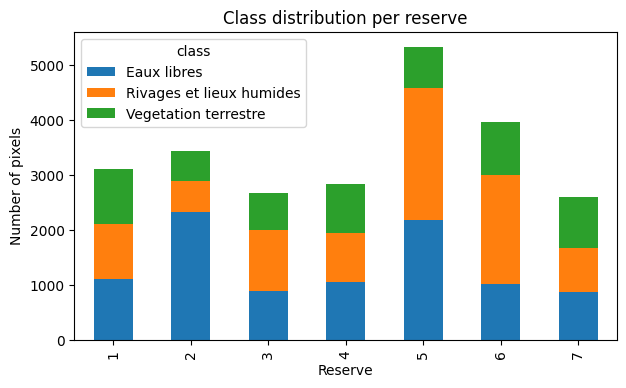

                 class A                  class B    JM
             Eaux libres Rivages et lieux humides 1.652
             Eaux libres     Vegetation terrestre 1.969
Rivages et lieux humides     Vegetation terrestre 1.291


In [4]:
#%% 3. characteristi
print(df[PRED].describe().T.round(3))

# class distribution per reserve
tab = pd.crosstab(df['class'].map(CLASS_NAMES), df['reserve_id'])
print(tab)

fig, ax = plt.subplots(figsize=(7,4))
tab.T.plot(kind='bar', stacked=True, ax=ax)
ax.set_xlabel('Reserve'); ax.set_ylabel('Number of pixels')
ax.set_title('Class distribution per reserve')
plt.savefig('fig_class_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

#%% 4. spectral separability (Jeffries-Matusita distance)
def jm(a, b):
    m1, m2 = a.mean(0), b.mean(0)
    S1, S2 = np.cov(a, rowvar=False), np.cov(b, rowvar=False)
    S = (S1 + S2)/2
    d = m1 - m2
    t1 = 0.125 * d @ np.linalg.pinv(S) @ d
    _, l1 = np.linalg.slogdet(S1); _, l2 = np.linalg.slogdet(S2); _, l = np.linalg.slogdet(S)
    return 2 * (1 - np.exp(-(t1 + 0.5*(l - 0.5*(l1+l2)))))

rows = []
for i, j in combinations(sorted(df['class'].unique()), 2):
    rows.append((CLASS_NAMES[i], CLASS_NAMES[j],
                 round(jm(df[df['class']==i][PRED].values, df[df['class']==j][PRED].values), 3)))
print(pd.DataFrame(rows, columns=['class A','class B','JM']).to_string(index=False))

In [5]:
#%% 5. leave-one-reserve-out cross validation

results, pfi_rows, y_true_all, y_pred_all = [], [], [], []

for r in sorted(df.reserve_id.unique()):
    train, test = df[df.reserve_id != r], df[df.reserve_id == r]
    X_train, y_train = train[PRED], train['class']
    X_test,  y_test  = test[PRED],  test['class']
    cv = list(GroupKFold(n_splits=5).split(X_train, y_train, train['block_id']))

    sfs = SequentialFeatureSelector(RandomForestClassifier(n_estimators=30, random_state=42),
          n_features_to_select=6, direction='forward', scoring='f1_macro', cv=cv)
    sfs.fit(X_train, y_train)
    sel = list(X_train.columns[sfs.get_support()])

    # Random Forest hyperparameter search
    rf = GridSearchCV(RandomForestClassifier(random_state=42),
         {'n_estimators':[100,200], 'max_depth':[10,25]}, cv=cv, scoring='f1_macro')
    rf.fit(X_train[sel], y_train)

    # Multinomial logistic regression hyperparameter search
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(X_train[sel]), sc.transform(X_test[sel])
    mlr = GridSearchCV(LogisticRegression(max_iter=1000),
          {'C':[10,1.0,0.1]}, cv=cv, scoring='f1_macro')
    mlr.fit(Xtr_s, y_train)

    p_rf, p_mlr = rf.predict(X_test[sel]), mlr.predict(Xte_s)

    for name, pred, gs in [('RF', p_rf, rf), ('MLR', p_mlr, mlr)]:
        results.append({'reserve': r, 'model': name, 'features': sel,
                        'best_params': gs.best_params_,
                        'val_macro_f1': round(gs.best_score_, 3),
                        'accuracy': accuracy_score(y_test, pred),
                        'macro_f1': f1_score(y_test, pred, average='macro', zero_division=0),
                        'balanced_acc': balanced_accuracy_score(y_test, pred)})

    y_true_all.extend(y_test); y_pred_all.extend(p_rf)

    pfi = permutation_importance(rf.best_estimator_, X_test[sel], y_test,
                                 scoring='f1_macro', n_repeats=5, random_state=42)
    for f_, v in zip(sel, pfi.importances_mean):
        pfi_rows.append({'reserve': r, 'feature': f_, 'importance': v})

    print('reserve', r, 'done |', sel)

results_df = pd.DataFrame(results)
pfi_df = pd.DataFrame(pfi_rows)

reserve 1 done | ['blue', 'red', 'nir', 'swir2', 'elev_rel_lake', 'slope']
reserve 2 done | ['green', 'red', 'nir', 'swir1', 'elev_rel_lake', 'slope']
reserve 3 done | ['red', 'nir', 'swir1', 'MNDWI', 'elev_rel_lake', 'slope']
reserve 4 done | ['blue', 'red', 'nir', 'swir2', 'elev_rel_lake', 'slope']
reserve 5 done | ['blue', 'red', 'nir', 'swir1', 'elev_rel_lake', 'slope']
reserve 6 done | ['blue', 'red', 'nir', 'swir2', 'elev_rel_lake', 'slope']
reserve 7 done | ['blue', 'red', 'nir', 'swir1', 'elev_rel_lake', 'slope']


In [6]:
#%% 6. results tables
print('=== Per-fold results ===')
print(results_df[['reserve','model','val_macro_f1','accuracy','macro_f1','balanced_acc']].round(3))

print('\n=== Mean +/- sd across the 7 held-out reserves ===')
print(results_df.groupby('model')[['accuracy','macro_f1','balanced_acc']].agg(['mean','std']).round(3))

print('\n=== Hyperparameters selected per fold ===')
print(results_df[['reserve','model','best_params']].to_string(index=False))

print('\n=== Features selected per fold ===')
for _, row in results_df[results_df.model=='RF'].iterrows():
    print(row['reserve'], row['features'])

#%% 7. confusion matrix and per-class metrics (RF, all folds pooled)
print(confusion_matrix(y_true_all, y_pred_all))
print(classification_report(y_true_all, y_pred_all, labels=[1,2,3],
      target_names=[CLASS_NAMES[c] for c in [1,2,3]], zero_division=0))

#%% 8. feature importance (permutation, on held-out reserves)
pfi_sum = pfi_df.groupby('feature')['importance'].agg(['mean','std']).sort_values('mean', ascending=False)
print(pfi_sum.round(4))

=== Per-fold results ===
    reserve model  val_macro_f1  accuracy  macro_f1  balanced_acc
0         1    RF         0.740     0.605     0.611         0.604
1         1   MLR         0.702     0.643     0.624         0.632
2         2    RF         0.724     0.786     0.628         0.598
3         2   MLR         0.694     0.787     0.628         0.589
4         3    RF         0.744     0.642     0.633         0.643
5         3   MLR         0.706     0.626     0.613         0.630
6         4    RF         0.737     0.585     0.592         0.595
7         4   MLR         0.697     0.671     0.670         0.665
8         5    RF         0.715     0.760     0.720         0.729
9         5   MLR         0.681     0.776     0.745         0.737
10        6    RF         0.732     0.689     0.693         0.722
11        6   MLR         0.696     0.674     0.677         0.715
12        7    RF         0.725     0.528     0.488         0.524
13        7   MLR         0.708     0.598     0.585

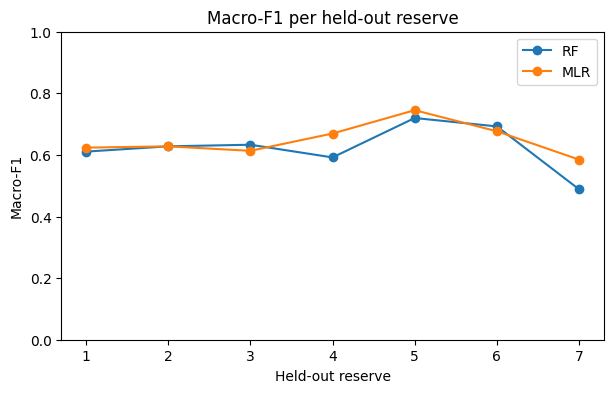

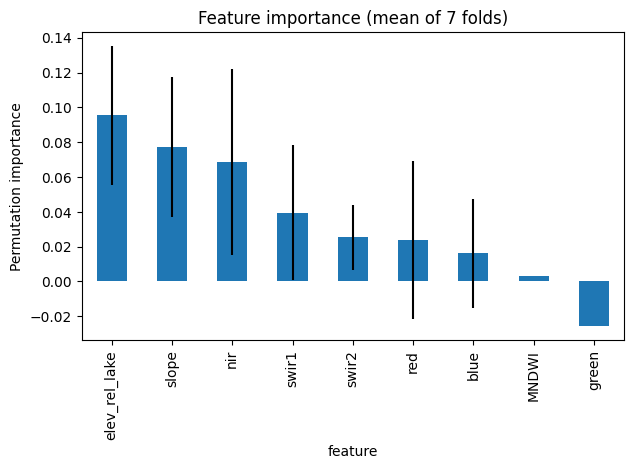

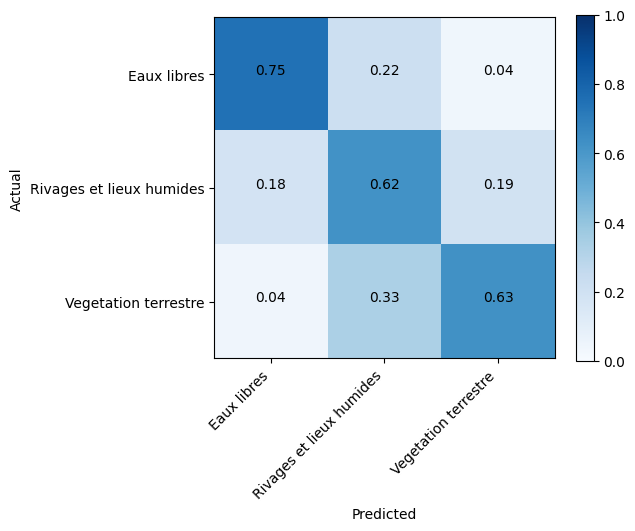

In [7]:
#%% 9. figures
# macro-F1 per reserve
fig, ax = plt.subplots(figsize=(7,4))
for m in ['RF','MLR']:
    s = results_df[results_df.model==m]
    ax.plot(s['reserve'], s['macro_f1'], marker='o', label=m)
ax.set_xlabel('Held-out reserve'); ax.set_ylabel('Macro-F1'); ax.set_ylim(0,1)
ax.legend(); ax.set_title('Macro-F1 per held-out reserve')
plt.savefig('fig_macro_f1.png', dpi=150, bbox_inches='tight'); plt.show()

# feature importance
fig, ax = plt.subplots(figsize=(7,4))
pfi_sum['mean'].plot(kind='bar', yerr=pfi_sum['std'], ax=ax)
ax.set_ylabel('Permutation importance'); ax.set_title('Feature importance (mean of 7 folds)')
plt.savefig('fig_importance.png', dpi=150, bbox_inches='tight'); plt.show()

# confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, normalize='true')
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
lbl = [CLASS_NAMES[c] for c in [1,2,3]]
ax.set_xticks(range(3)); ax.set_xticklabels(lbl, rotation=45, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(lbl)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); plt.colorbar(im)
plt.savefig('fig_confusion.png', dpi=150, bbox_inches='tight'); plt.show()

Final features: ['swir1', 'swir2', 'NDMI', 'NBR', 'elev_rel_lake', 'slope']
Final parameters: {'max_depth': 10, 'n_estimators': 100}
data/GC_predictors_2011_deploy_r8_r9.tif: 3132 valid pixels of 832616


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


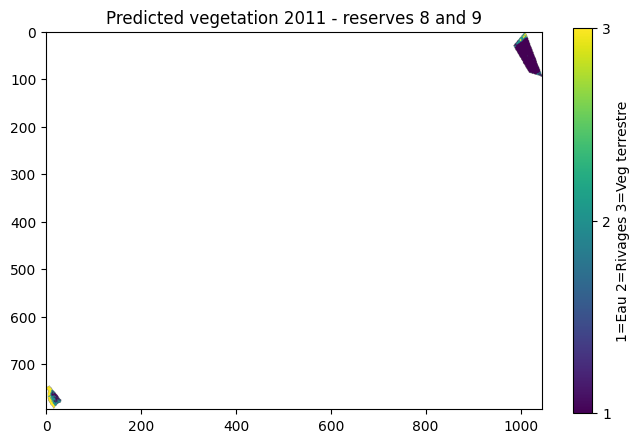

data/GC_predictors_2025_exploratory.tif: 27796 valid pixels of 901888


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


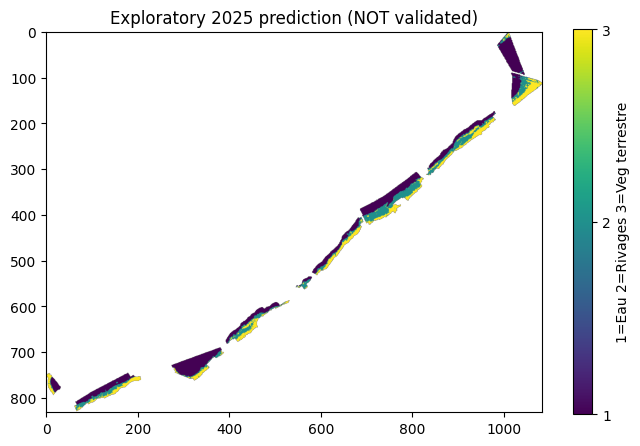

In [8]:
#%% 10. final model trained on all 7 reserves
X_all, y_all = df[PRED], df['class']
cv_all = list(GroupKFold(n_splits=7).split(X_all, y_all, df['reserve_id']))

sfs_f = SequentialFeatureSelector(RandomForestClassifier(n_estimators=30, random_state=42),
        n_features_to_select=6, direction='forward', scoring='f1_macro', cv=cv_all)
sfs_f.fit(X_all, y_all)
final_feats = list(X_all.columns[sfs_f.get_support()])

rf_f = GridSearchCV(RandomForestClassifier(random_state=42),
       {'n_estimators':[100,200], 'max_depth':[10,25]}, cv=cv_all, scoring='f1_macro')
rf_f.fit(X_all[final_feats], y_all)
final_model = rf_f.best_estimator_
print('Final features:', final_feats)
print('Final parameters:', rf_f.best_params_)

#%% 11. maps
BANDS = ['blue','green','red','nir','swir1','swir2','NDVI','NDMI','MNDWI','NBR',
         'elev_rel_lake','slope','dist_to_water']   # band order in the GeoTIFFs

def predict_raster(tif, out, model, feats):
    with rasterio.open(tif) as src:
        arr, prof = src.read(), src.profile
    idx = [BANDS.index(f) for f in feats]
    stack = arr[idx]
    h, w = stack.shape[1], stack.shape[2]
    flat = stack.reshape(len(feats), -1).T
    ok = np.isfinite(flat).all(axis=1)
    print(f'{tif}: {ok.sum()} valid pixels of {len(flat)}')
    out_arr = np.zeros(flat.shape[0], dtype='uint8')
    if ok.sum() > 0:
        out_arr[ok] = model.predict(flat[ok])
    out_arr = out_arr.reshape(h, w)
    prof.update(count=1, dtype='uint8', nodata=0)
    with rasterio.open(out, 'w', **prof) as dst:
        dst.write(out_arr, 1)
    return out_arr

def show(a, title, fname):
    plt.figure(figsize=(8,5))
    plt.imshow(np.ma.masked_equal(a, 0), cmap='viridis', vmin=1, vmax=3)
    plt.title(title); plt.colorbar(ticks=[1,2,3], label='1=Eau 2=Rivages 3=Veg terrestre')
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()

# 2011 prediction for the unmapped reserves 8 and 9
m2011 = predict_raster('data/GC_predictors_2011_deploy_r8_r9.tif',
                       'pred_2011_reserves_8_9.tif', final_model, final_feats)
show(m2011, 'Predicted vegetation 2011 - reserves 8 and 9', 'fig_map_2011.png')

# 2025 exploratory transfer
# NOT a validated map: no 2025 ground truth exists, so its accuracy is
# unknown. Differences from 2011 mix real vegetation change, phenology,
# acquisition date and Landsat 5 vs 8/9 sensor differences, which cannot
# be separated without field data.
m2025 = predict_raster('data/GC_predictors_2025_exploratory.tif',
                       'pred_2025_exploratory.tif', final_model, final_feats)
show(m2025, 'Exploratory 2025 prediction (NOT validated)', 'fig_map_2025.png')